In [17]:

# basic packages
import pandas as pd
import numpy as np
import datetime as dt
from pytz import timezone
import urllib
import os
import math
from scipy import stats
from scipy.signal import find_peaks, spectrogram
import seaborn as sns


# packages for visualizations
import matplotlib.dates as mdates

from matplotlib import pyplot as plt
import glob


In [18]:
ev_load = './cleansed_data_HP/combined_HP_data.csv'

# Read only the first 2 million rows
df = pd.read_csv(ev_load, nrows=9000000)

df


,Timestamp,Circulation_Pump_Energy_Consumed,External_Air_Temperature,Heat_Pump_Energy_Output,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Hot_Water_Flow_Temperature,Internal_Air_Temperature,Whole_System_Energy_Consumed,Property_ID,Immersion_Heater_Energy_Consumed,Boiler_Energy_Output,Brine_Flow_Temperature,Brine_Return_Temperature,Back-up_Heater_Energy_Consumed
0,2021-07-02 11:12:00,0.000,16.20,NaN,NaN,NaN,NaN,NaN,NaN,EOH1328,NaN,NaN,NaN,NaN,NaN
1,2021-07-02 11:14:00,0.000,16.23,NaN,NaN,NaN,NaN,NaN,0.000,EOH1328,NaN,NaN,NaN,NaN,NaN
2,2021-07-02 11:16:00,NaN,16.27,NaN,NaN,NaN,NaN,NaN,NaN,EOH1328,NaN,NaN,NaN,NaN,NaN
3,2021-07-02 11:18:00,0.000,16.30,NaN,NaN,NaN,NaN,NaN,0.158,EOH1328,NaN,NaN,NaN,NaN,NaN
4,2021-07-02 11:20:00,0.001,16.33,NaN,NaN,NaN,NaN,NaN,0.294,EOH1328,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8999995,2021-11-27 04:22:00,0.000,3.74,1813.029,50.46,50.24,NaN,10.01,1673.024,EOH2192,158.444,NaN,NaN,NaN,NaN
8999996,2021-11-27 04:24:00,0.000,3.72,1813.029,50.11,50.07,NaN,10.01,1673.027,EOH2192,158.444,NaN,NaN,NaN,NaN
8999997,2021-11-27 04:26:00,0.000,3.70,1813.029,49.21,49.17,NaN,10.01,1673.029,EOH2192,158.444,NaN,NaN,NaN,NaN
8999998,2021-11-27 04:28:00,0.000,3.67,1813.031,48.85,48.27,NaN,10.01,1673.030,EOH2192,158.444,NaN,NaN,NaN,NaN


In [19]:

# Convert 'Timestamp' to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Sort the DataFrame by 'Property_ID' and 'Timestamp'
df = df.sort_values(by=['Property_ID', 'Timestamp'])

# Extract 'Date' and 'Hour' from 'Timestamp'
df['Date'] = df['Timestamp'].dt.date
df['Hour'] = df['Timestamp'].dt.hour

# Group by 'Property_ID' and 'Date'
grouped = df.groupby(['Property_ID', 'Date'])

# Calculate the difference in cumulative energy
df['Hourly_Energy_Consumed'] = grouped['Whole_System_Energy_Consumed'].diff()

# Remove negative or zero consumption values if necessary
df = df[df['Hourly_Energy_Consumed'] > 0]

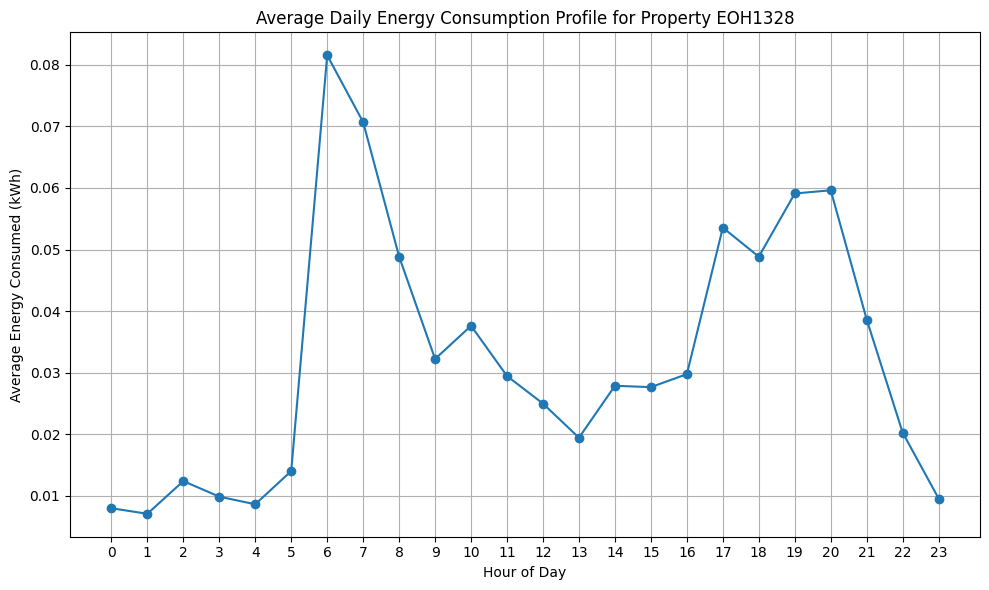

In [20]:
# Filter the data for the specific property
df_property = df[df['Property_ID'] == 'EOH1328']
# Group by 'Hour' and calculate the mean
average_profile = df_property.groupby('Hour')['Hourly_Energy_Consumed'].mean()

import matplotlib.pyplot as plt

# Plot the average daily energy consumption profile
plt.figure(figsize=(10, 6))
plt.plot(average_profile.index, average_profile.values, marker='o')
plt.title('Average Daily Energy Consumption Profile for Property EOH1328')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumed (kWh)')
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


In [21]:
# Define winter and summer months
winter_months = [12, 1, 2]  # December, January, February
summer_months = [6, 7, 8]   # June, July, August


/var/folders/s4/22x3mwpj4bldz0pl87jpf5th0000gn/T/ipykernel_10983/37826462.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])
/var/folders/s4/22x3mwpj4bldz0pl87jpf5th0000gn/T/ipykernel_10983/37826462.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Timestamp'].dt.month
/var/folders/s4/22x3mwpj4bldz0pl87jpf5th0000gn/T/ipykernel_10983/37826462.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

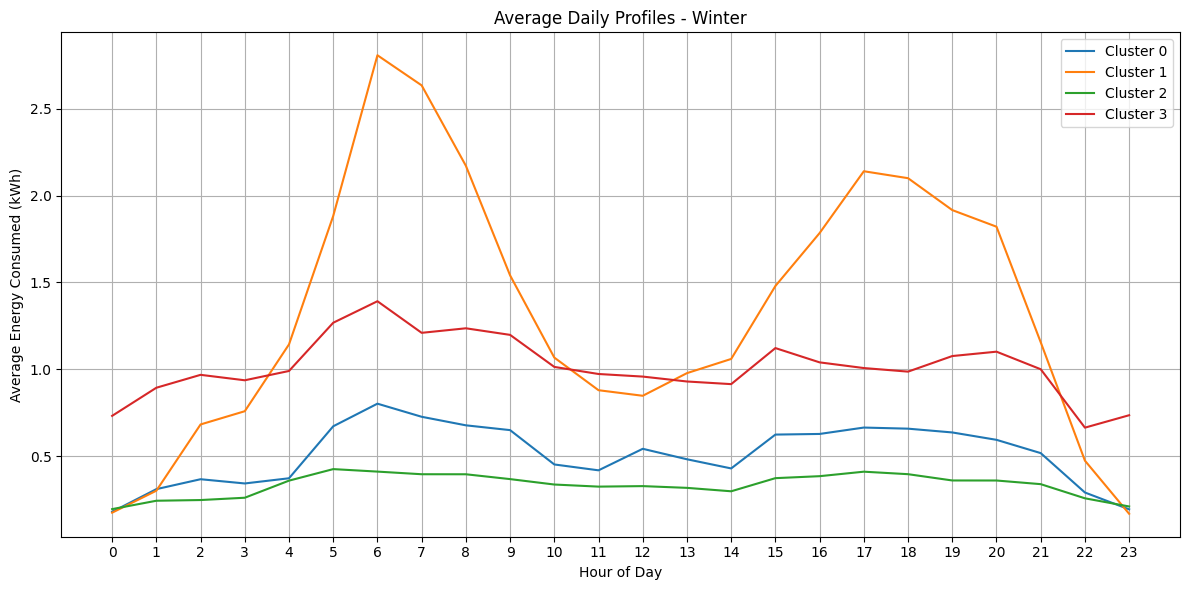

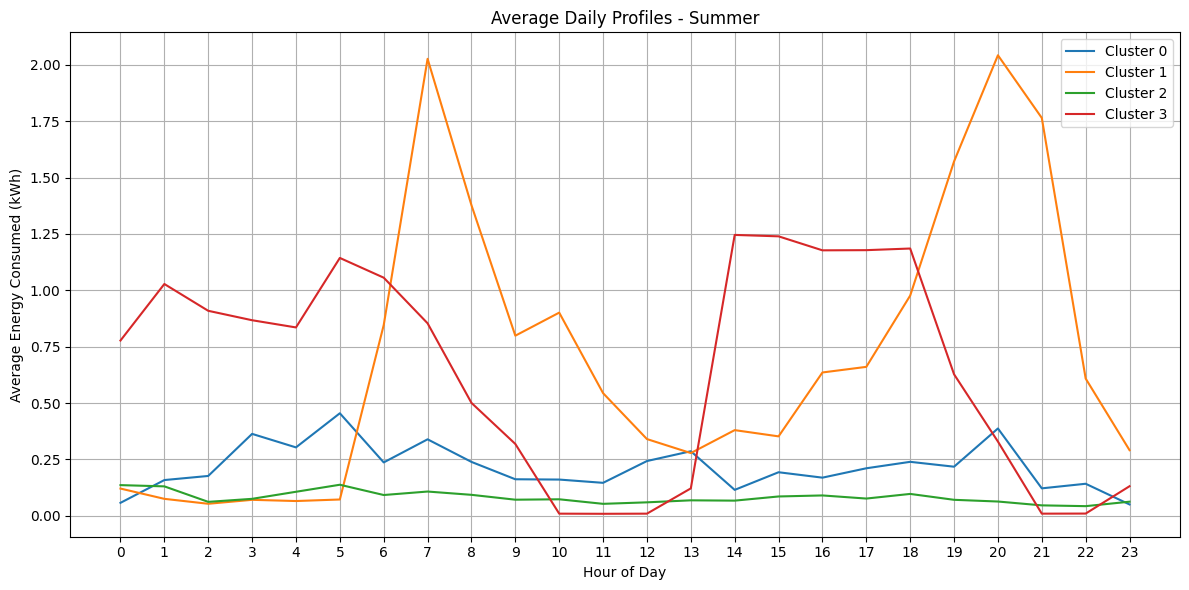

In [22]:
import pandas as pd

# Convert 'Timestamp' to datetime if not already
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract month, day, and hour
df['Month'] = df['Timestamp'].dt.month
df['Date'] = df['Timestamp'].dt.date
df['Hour'] = df['Timestamp'].dt.hour

# Sort data
df = df.sort_values(by=['Property_ID', 'Timestamp'])

# Group by 'Property_ID' and 'Date'
grouped = df.groupby(['Property_ID', 'Date'])

# Calculate hourly consumption
df['Hourly_Energy_Consumed'] = grouped['Whole_System_Energy_Consumed'].diff()

# Remove negative or zero consumption values
df = df[df['Hourly_Energy_Consumed'] > 0]


# Define seasons
df['Month'] = df['Timestamp'].dt.month
df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else ('Summer' if x in [6, 7, 8] else 'Other'))

# Filter for Winter and Summer
df_seasonal = df[df['Season'].isin(['Winter', 'Summer'])]


# Group by 'Property_ID', 'Date', and 'Hour' to get hourly consumption
df_hourly = df_seasonal.groupby(['Property_ID', 'Date', 'Hour'])['Hourly_Energy_Consumed'].sum().reset_index()

# Pivot to create daily profiles
df_pivot = df_hourly.pivot_table(index=['Property_ID', 'Date'], columns='Hour', values='Hourly_Energy_Consumed')

# Handle missing hours by filling with zeros
df_pivot = df_pivot.fillna(0)

from tslearn.utils import to_time_series_dataset

# Convert to time series dataset
X = to_time_series_dataset(df_pivot.values)

from tslearn.clustering import TimeSeriesKMeans

# Define number of clusters
n_clusters = 4

# Initialize and fit the model
model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=42)
labels = model.fit_predict(X)

# Add cluster labels to the DataFrame
df_pivot['Cluster'] = labels

# Reset index to merge
df_pivot_reset = df_pivot.reset_index()

# Merge with season information
df_clusters = pd.merge(df_pivot_reset, df[['Property_ID', 'Date', 'Season']], on=['Property_ID', 'Date'], how='left')

# Filter for Winter and Summer
df_clusters_seasonal = df_clusters[df_clusters['Season'].isin(['Winter', 'Summer'])]

import matplotlib.pyplot as plt

# Define hours
hours = list(range(24))

# Plot for each season
for season in ['Winter', 'Summer']:
    plt.figure(figsize=(12, 6))
    for cluster in range(n_clusters):
        # Filter data for the season and cluster
        cluster_data = df_clusters_seasonal[(df_clusters_seasonal['Season'] == season) & (df_clusters_seasonal['Cluster'] == cluster)]
        
        # Calculate mean profile
        mean_profile = cluster_data[hours].mean()
        
        # Plot
        plt.plot(hours, mean_profile, label=f'Cluster {cluster}')
    
    plt.title(f'Average Daily Profiles - {season}')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Energy Consumed (kWh)')
    plt.legend()
    plt.grid(True)
    plt.xticks(hours)
    plt.tight_layout()
    plt.show()

